<a href="https://colab.research.google.com/github/watch-duty/radio-transcription/blob/merge_manifests/model/colabs/evaluate_transcriptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Colab to compute metrics from a JSON manifest with transcriptions from various models.

The google drive version of this colab (for iterating and editing) [is here](https://colab.research.google.com/drive/1HJs9lUMsg5dyK4uwuLmzxzbtKEE9tkbi?authuser=1#scrollTo=72af-Ue2_BwC). Once you have a unit of edit completed, you can check-in the drive version into [this github directory](https://github.com/watch-duty/radio-transcription/tree/main/model/colabs).

**Dependencies**: The key libraries used are *jiwer* (for WER calculation)
and *nemo_text_processing* for normalizing numbers. You can pip install
them from the colab or have them installed in your local jupyter kernel
if you are running the kernel from your desktop. Eventually we will have a
custom jupyter kernel running that can be shared across users.

In [16]:
#@title Imports
import json
import os
import jiwer
import re
from nemo_text_processing.text_normalization.normalize import Normalizer as NemoNormalizer
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


inference_results = "/usr/local/google/home/varungulshan/radio-transcription/model/data/inference_manifests/playground_all_models.jsonl"  #@param
postfixes_to_eval = ['chirp_v3_with_context', 'chirp_v3_no_context', 'gemma3n', 'parakeet-tdt-06b-v2', 'canary-1b-flash']  #@param
eval_output = "/tmp/playground_per_sample_eval.json" #@param



In [10]:
#@title Init the Nemo text processor

# Doing this in a separate cell because this processor is a little
# slow to load.

# Initialize the normalizer for English only here.
nemo_normalizer = NemoNormalizer(input_case='cased', lang='en')

 NeMo-text-processing :: INFO     :: Creating ClassifyFst grammars.


In [27]:
#@title Helper functions

# See the documentation of the NeMO normalization function here:
# https://docs.nvidia.com/nemo-framework/user-guide/24.12/nemotoolkit/nlp/text_normalization/wfst/wfst_text_normalization.html
# This normalizer converts all kinds of numbers/dates/times into a canonical
# format.
# TODO: This is quite slow to run right now, so look into either distributing
# the eval, or getting this to run faster (if there is any configurability).
# Or maybe just use Rob's num2words library if that covers all the cases
# we expect to run into?
class NemoNormalization(jiwer.AbstractTransform):
  def process_string(self, s: str) -> str:
    normalized_text = nemo_normalizer.normalize(s, verbose=False)
    return normalized_text

# These jiwer ops here are copied over from Rob's original colab
# that evaluated Chirp at:
# https://colab.research.google.com/drive/1qVFdCJy_5HNBAnUyMcpuZmGTodL-fPgX
class NormalizeDispatchQuirks(jiwer.AbstractTransform):
    def process_string(self, s: str) -> str:
        # TODO: This is disabled right now -- we need to handle <unknown>
        # text in the WER calculation, and not by simply removing it.
        # Strip underscore placeholders (treat like <unknown>)
        # s = re.sub(r"_+", "", s)

        # Strip fillers (uh, um, ah, er) so models aren't penalized for readability
        s = re.sub(r"\b(uh|um|ah|er)\b", "", s, flags=re.IGNORECASE)

        # Turn hyphens into spaces (e.g., "14A-alpha" -> "14A alpha")
        # Prevents words from getting glued together when punctuation is removed
        s = s.replace("-", " ")

        return s

def run_jiwer_evaluation(input_json, output_json, postfixes_to_evaluate):
  gt_text_field = "text"
  prediction_field_prefix = "pred_text_"

  # Much of the jiwer ops here are copied over from Rob's original colab
  # that evaluated Chirp at:
  # https://colab.research.google.com/drive/1qVFdCJy_5HNBAnUyMcpuZmGTodL-fPgX
  normalization_ops = jiwer.Compose([
    NemoNormalization(),
    NormalizeDispatchQuirks(),
    jiwer.SubstituteRegexes({r"[\n\r\t]+": " "}),
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.RemoveWhiteSpace(replace_by_space=True),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
  ])

  with open(input_json, 'r', encoding='utf-8') as f:
    with open(output_json, 'w', encoding='utf-8') as out:
      # The lists below store all the ground truth and prediction
      # data to compute aggregate metric across the entire dataset.
      # The ground truth and prediction texts are stored after
      # applying the normalization ops.
      all_ground_truths = []
      all_predictions_by_postfix = {}
      for postfix in postfixes_to_evaluate:
        all_predictions_by_postfix[postfix] = []

      # Iterate through each utterance output in the json
      for line in f:
        data_row = json.loads(line)
        audio_filepath = data_row["audio_filepath"]
        ground_truth_text = [data_row.get(gt_text_field, "")]
        if not ground_truth_text:
          print(f"Skipping example: {audio_filepath}, ground truth is empty")
          continue
        ground_truth_text = normalization_ops(ground_truth_text)
        all_ground_truths.extend(ground_truth_text)

        output_row = data_row
        for postfix in postfixes_to_eval:
          pred_text_field = prediction_field_prefix + postfix
          predicted_text = [data_row.get(pred_text_field)]
          if predicted_text[0] is None:
            raise ValueError(f"Expected field: {pred_text_field} to be populated for example: {audio_filepath}")
          predicted_text = normalization_ops(predicted_text)
          all_predictions_by_postfix[postfix].extend(predicted_text)

          sample_eval_output = jiwer.process_words(ground_truth_text,
                                                   predicted_text,
                                                   jiwer.ReduceToListOfListOfWords(),
                                                   jiwer.ReduceToListOfListOfWords())
          sample_wer = round(100 * sample_eval_output.wer, 2)
          output_row["wer_" + postfix] = sample_wer

          # We also save the processed text strings, so we can investigate how
          # we are transforming the text before eval.
          output_row[pred_text_field + "_processed"] = " ".join(sample_eval_output.hypotheses[0])
          output_row[gt_text_field + "_processed"] = " ".join(sample_eval_output.references[0])

        # Write as a JSON line
        out.write(json.dumps(output_row, sort_keys=True) + '\n')

      # Compute cross dataset metric.
      dataset_summary = []
      for postfix in postfixes_to_eval:
        wer_output = jiwer.process_words(all_ground_truths,
                                         all_predictions_by_postfix[postfix],
                                         jiwer.ReduceToListOfListOfWords(),
                                         jiwer.ReduceToListOfListOfWords())
        dataset_wer = round(100 * wer_output.wer, 2)
        num_words = wer_output.hits + wer_output.substitutions + wer_output.deletions
        dataset_summary.append({
            "Model": postfix,
            "WER": dataset_wer,
            "Num Words": num_words,
            "Substitutions": wer_output.substitutions,
            "Insertions": wer_output.insertions,
            "Deletions": wer_output.deletions,
            })

  print(f"Successfully evaluated {input_json}\nWrote per sample evaluation to: {output_json}")
  print(f"Total number of utterances: {len(all_ground_truths)}")
  speech_explorer_cmd = f"""
  python tools/speech_data_explorer/data_explorer.py \\
  --port 8081 \\
  {output_json}
  """
  print(f"\nYou can run this speech data explorer from the NeMO codebase to browse the results:\n{speech_explorer_cmd}")
  return pd.DataFrame(dataset_summary)

def plot_wer_per_model(wer_df):
  # Plotting code borrowed from Rob's colab here:
  # https://colab.sandbox.google.com/drive/1qVFdCJy_5HNBAnUyMcpuZmGTodL-fPgX#scrollTo=4NRiLl31V6qM
  plt.figure(figsize=(10, 6))
  sns.barplot(x="Model", y="WER", hue="Model", data=wer_df, palette="viridis", legend=False)
  for index, value in enumerate(wer_df["WER"]):
      plt.text(index, value + 0.5, f"{value:.2f}%", ha="center", fontweight="bold")
  plt.title("Word Error Rate (WER) by Model", fontsize=14)
  plt.show()

Successfully evaluated /usr/local/google/home/varungulshan/radio-transcription/model/data/inference_manifests/playground_all_models.jsonl
Wrote per sample evaluation to: /tmp/playground_per_sample_eval.json
Total number of utterances: 35

You can run this speech data explorer from the NeMO codebase to browse the results:

  python tools/speech_data_explorer/data_explorer.py \
  --port 8081 \
  /tmp/playground_per_sample_eval.json
  


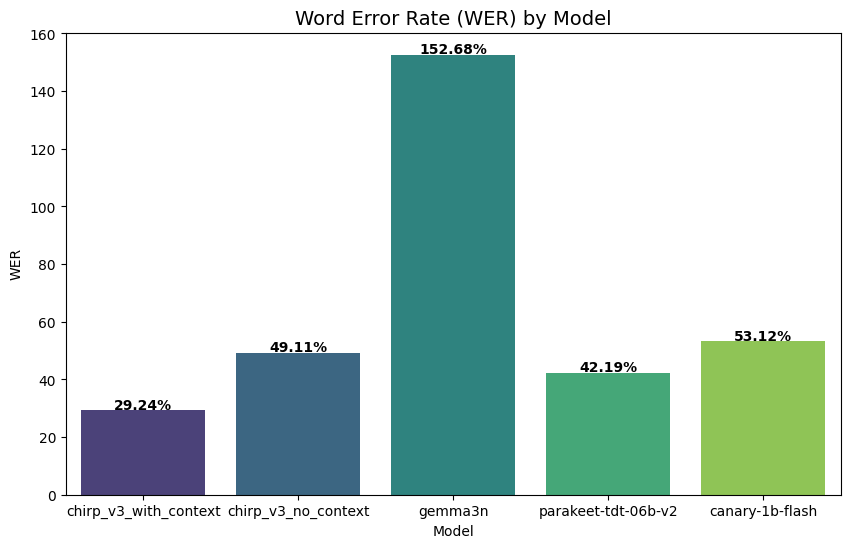

,Model,WER,Num Words,Substitutions,Insertions,Deletions
0,chirp_v3_with_context,29.24,448,57,25,49
1,chirp_v3_no_context,49.11,448,134,54,32
2,gemma3n,152.68,448,212,369,103
3,parakeet-tdt-06b-v2,42.19,448,111,42,36
4,canary-1b-flash,53.12,448,101,36,101


In [28]:
wer_df = run_jiwer_evaluation(inference_results, eval_output, postfixes_to_eval)
plot_wer_per_model(wer_df)
display(wer_df)